# Browse DestinE Climate DT Data with Polytope

This notebook demonstrates how to browse and explore DestinE Climate Digital Twin data
using Polytope and `earthkit-data`, focusing on the **ICON**, **IFS-FESOM**, and
**IFS-NEMO** models with applications for rainfall analysis over Africa.

> **Important — Server addresses:** ICON and IFS-FESOM data are served from
> `polytope.lumi.apps.dte.destination-earth.eu` (LUMI), while IFS-NEMO data
> comes from `polytope.mn5.apps.dte.destination-earth.eu` (MN5).
> **Experiment keywords:** Use abbreviated names: `'hist'` for historical,
> `'cont'` for control, `'SSP3-7.0'` for projections. Use `activity='baseline'`
> for hist/cont experiments and `activity='projections'` for SSP3-7.0.
> **Streams:** The hourly `clte` stream contains instantaneous surface
> parameters (134 SP, 165 10U, 166 10V). Precipitation (228228) and
> temperature (167) require the monthly `clmn` stream or the
> `PolytopeZarrStore` approach from polytope-examples.

## Prerequisites
- Conda environment `destine` with `earthkit-data`, `polytope-client`, `covjsonkit` installed
- DestinE Platform account with upgraded access
- Authentication configured (`~/.polytopeapirc`)

See `docs/polytope_setup.md` for detailed setup instructions.

## 1. Imports and Configuration

In [12]:
import earthkit.data
import os

# Polytope server configuration
# ICON and IFS-FESOM → LUMI  |  IFS-NEMO → MN5
LUMI_ADDRESS = "polytope.lumi.apps.dte.destination-earth.eu"
MN5_ADDRESS  = "polytope.mn5.apps.dte.destination-earth.eu"
COLLECTION   = "destination-earth"

# Helper: get field count from earthkit-data results
# GribData objects have no __len__ and no __iter__;
# we count fields via to_xarray()
def safe_len(data) -> int:
    """Count fields in an earthkit-data result, even for GribData."""
    try:
        return len(data)
    except TypeError:
        pass
    # GribData: no __len__, no __iter__ - use to_xarray()
    try:
        ds = data.to_xarray()
        return sum(
            ds[var].size for var in ds.data_vars
        )
    except Exception:
        return 1  # at least we have data

def peek_metadata(data, n=3):
    """Print brief metadata summary from earthkit-data result."""
    try:
        ds = data.to_xarray()
        print(f"  Variables: {list(ds.data_vars)}")
        for var in list(ds.data_vars)[:n]:
            print(f"    {var}: {ds[var].dims} shape={ds[var].shape}")
    except Exception as e:
        print(f"  (metadata unavailable: {e})")

# Helper: pick the right address based on model
def get_address(model: str) -> str:
    """Return the correct Polytope server address for a given model."""
    if model == "IFS-NEMO":
        return MN5_ADDRESS
    return LUMI_ADDRESS  # ICON, IFS-FESOM, and others

print(f"earthkit-data version: {earthkit.data.__version__}")
print(f"LUMI address: {LUMI_ADDRESS}")
print(f"MN5  address: {MN5_ADDRESS}")


earthkit-data version: 1.0.2
LUMI address: polytope.lumi.apps.dte.destination-earth.eu
MN5  address: polytope.mn5.apps.dte.destination-earth.eu


## 2. Quick Connection Test

Make a small test request to verify connectivity and authentication
for each server (LUMI and MN5).

In [13]:
# Test LUMI (ICON) — historical simulation, single parameter
print("Testing LUMI server (ICON historical)...")
try:
    lumidata = earthkit.data.from_source(
        "polytope", COLLECTION,
        {
            'activity': 'baseline',
            'class': 'd1',
            'dataset': 'climate-dt',
            'date': '20000615',
            'experiment': 'hist',
            'expver': '0001',
            'generation': '2',
            'levtype': 'sfc',
            'model': 'ICON',
            'param': '134',            # Surface pressure
            'realization': '1',
            'resolution': 'standard',
            'stream': 'clte',
            'time': '0000',
            'type': 'fc'
        },
        address=LUMI_ADDRESS,
        stream=False
    )
    print(f"  ✓ LUMI OK — {safe_len(lumidata)} field(s)")
except Exception as e:
    print(f"  ✗ LUMI failed: {e}")

# Test MN5 (IFS-NEMO) — projections
print("Testing MN5 server (IFS-NEMO SSP3-7.0)...")
try:
    mn5data = earthkit.data.from_source(
        "polytope", COLLECTION,
        {
            'activity': 'projections',
            'class': 'd1',
            'dataset': 'climate-dt',
            'date': '20200102',
            'experiment': 'SSP3-7.0',
            'expver': '0001',
            'generation': '2',
            'levtype': 'sfc',
            'model': 'IFS-NEMO',
            'param': '134/165/166',   # SP, 10U, 10V
            'realization': '1',
            'resolution': 'standard',
            'stream': 'clte',
            'time': '0100',
            'type': 'fc'
        },
        address=MN5_ADDRESS,
        stream=False
    )
    print(f"  ✓ MN5  OK — {safe_len(mn5data)} field(s)")
    print(mn5data)
except Exception as e:
    print(f"  ✗ MN5  failed: {e}")

2026-07-15 15:06:20 - INFO - Key read from /home/dorian.spat/.polytopeapirc
2026-07-15 15:06:20 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20000615'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ICON\n'
            "param: '134'\n"
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-07-15 15:06:20 - INFO - Polytope user key found in session cache for user dorian.spat


Testing LUMI server (ICON historical)...


2026-07-15 15:06:21 - INFO - Request accepted. Please poll ./ead12384-0f96-402e-ae57-937496dfc463 for status
2026-07-15 15:06:21 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-15 15:06:21 - INFO - Checking request status (ead12384-0f96-402e-ae57-937496dfc463)...
2026-07-15 15:06:21 - INFO - The current status of the request is 'queued'
2026-07-15 15:06:22 - INFO - The current status of the request is 'processing'
2026-07-15 15:06:25 - INFO - The current status of the request is 'processed'


ead12384-0f96-402e-ae57-937496dfc463.grib:   0%|          | 0.00/236k [00:00<?, ?B/s]

2026-07-15 15:06:26 - INFO - Key read from /home/dorian.spat/.polytopeapirc
2026-07-15 15:06:26 - INFO - Sending request...
{'request': 'activity: projections\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20200102'\n"
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            'param: 134/165/166\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0100'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-07-15 15:06:26 - INFO - Polytope user key found in session cache for user dorian.spat


  ✓ LUMI OK — 196608 field(s)
Testing MN5 server (IFS-NEMO SSP3-7.0)...


2026-07-15 15:06:27 - INFO - Request accepted. Please poll ./d7adb03c-db77-4b2c-8535-0c76a0822b4f for status
2026-07-15 15:06:27 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-15 15:06:27 - INFO - Checking request status (d7adb03c-db77-4b2c-8535-0c76a0822b4f)...
2026-07-15 15:06:27 - INFO - The current status of the request is 'queued'
2026-07-15 15:06:28 - INFO - The current status of the request is 'processing'
2026-07-15 15:06:30 - INFO - The current status of the request is 'processed'


d7adb03c-db77-4b2c-8535-0c76a0822b4f.grib:   0%|          | 0.00/1.35M [00:00<?, ?B/s]

  ✓ MN5  OK — 589824 field(s)
GribData(path=/tmp/tmpn88ky9sy/polytope-d884f9121d3d72b3e27723dba72f3a3df029feacd44d3e632c1f4cd9143bc9d5.cache)


## 3. Browse Available Data

Explore data availability for different models and experiments.
All examples use the hourly `clte` stream with surface variables
SP (134), 10U (165), and 10V (166).

### 3.1 ICON — Control Simulation (1950 forcing)

Control simulations represent present-day climate with fixed forcing.
Use `activity='baseline'` and `experiment='cont'`. Data is available
from the early 1990s on LUMI.

In [14]:
# ICON control simulation — surface variables, one day
icon_control_request = {
    'activity': 'baseline',
    'class': 'd1',
    'dataset': 'climate-dt',
    'date': '19900102',
    'experiment': 'cont',
    'expver': '0001',
    'generation': '2',
    'levtype': 'sfc',
    'model': 'ICON',
    'param': '134/165/166',    # SP, 10U, 10V
    'realization': '1',
    'resolution': 'standard',
    'stream': 'clte',
    'time': '0000/0300/0600/0900/1200/1500/1800/2100',  # All 3-hourly steps
    'type': 'fc'
}

print("Requesting ICON control data (LUMI)...")
try:
    icon_data = earthkit.data.from_source(
        "polytope",
        COLLECTION,
        icon_control_request,
        address=get_address('ICON'),
        stream=False
    )
    print(f"✓ Retrieved {safe_len(icon_data)} field(s)")
    peek_metadata(icon_data)
except Exception as e:
    print(f"✗ Error: {e}")


2026-07-15 15:06:33 - INFO - Key read from /home/dorian.spat/.polytopeapirc
2026-07-15 15:06:33 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '19900102'\n"
            'experiment: cont\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ICON\n'
            'param: 134/165/166\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0000/0300/0600/0900/1200/1500/1800/2100\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-07-15 15:06:33 - INFO - Polytope user key found in session cache for user dorian.spat


Requesting ICON control data (LUMI)...


2026-07-15 15:06:34 - INFO - Request accepted. Please poll ./eb8e51ae-cdd2-47d7-8d61-e76e74cfb286 for status
2026-07-15 15:06:34 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-15 15:06:34 - INFO - Checking request status (eb8e51ae-cdd2-47d7-8d61-e76e74cfb286)...
2026-07-15 15:06:34 - INFO - The current status of the request is 'queued'
2026-07-15 15:06:35 - INFO - The current status of the request is 'processing'
2026-07-15 15:06:38 - INFO - The current status of the request is 'processed'


eb8e51ae-cdd2-47d7-8d61-e76e74cfb286.grib:   0%|          | 0.00/6.58M [00:00<?, ?B/s]

✓ Retrieved 4718592 field(s)
  Variables: ['10u', '10v', 'sp']
    10u: ('forecast_reference_time', 'values') shape=(8, 196608)
    10v: ('forecast_reference_time', 'values') shape=(8, 196608)
    sp: ('forecast_reference_time', 'values') shape=(8, 196608)


### 3.2 ICON — Historical Simulation

Historical simulations cover 1950–2014 with observed forcing.
Use `activity='baseline'` and `experiment='hist'`.

In [15]:
# ICON historical simulation — surface pressure and winds
# (Precipitation/temperature require the monthly 'clmn' stream;
#  here we use surface variables available in the hourly 'clte' stream.)
icon_hist_request = {
    'activity': 'baseline',
    'class': 'd1',
    'dataset': 'climate-dt',
    'date': '20000615',           # Mid-June (wet season in West Africa)
    'experiment': 'hist',
    'expver': '0001',
    'generation': '2',
    'levtype': 'sfc',
    'model': 'ICON',
    'param': '134/165/166',        # SP, 10U, 10V
    'realization': '1',
    'resolution': 'standard',
    'stream': 'clte',
    'time': '0000/1200',
    'type': 'fc'
}

print("Requesting ICON historical surface data (LUMI)...")
try:
    icon_hist_data = earthkit.data.from_source(
        "polytope",
        COLLECTION,
        icon_hist_request,
        address=get_address('ICON'),
        stream=False
    )
    print(f"✓ Retrieved {safe_len(icon_hist_data)} field(s)")
    peek_metadata(icon_hist_data)
    # Convert to xarray
    ds = icon_hist_data.to_xarray()
    print(f"Dataset: {ds}")
except Exception as e:
    print(f"✗ Error: {e}")


2026-07-15 15:06:42 - INFO - Key read from /home/dorian.spat/.polytopeapirc
2026-07-15 15:06:42 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20000615'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: ICON\n'
            'param: 134/165/166\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0000/1200\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-07-15 15:06:42 - INFO - Polytope user key found in session cache for user dorian.spat


Requesting ICON historical surface data (LUMI)...


2026-07-15 15:06:42 - INFO - Request accepted. Please poll ./f1facf44-4c23-4d8e-9e88-34b000bdc08d for status
2026-07-15 15:06:42 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-15 15:06:42 - INFO - Checking request status (f1facf44-4c23-4d8e-9e88-34b000bdc08d)...
2026-07-15 15:06:43 - INFO - The current status of the request is 'queued'
2026-07-15 15:06:43 - INFO - The current status of the request is 'processing'
2026-07-15 15:06:46 - INFO - The current status of the request is 'processed'


f1facf44-4c23-4d8e-9e88-34b000bdc08d.grib:   0%|          | 0.00/1.68M [00:00<?, ?B/s]

✓ Retrieved 1179648 field(s)
  Variables: ['10u', '10v', 'sp']
    10u: ('forecast_reference_time', 'values') shape=(2, 196608)
    10v: ('forecast_reference_time', 'values') shape=(2, 196608)
    sp: ('forecast_reference_time', 'values') shape=(2, 196608)
Dataset: <xarray.Dataset> Size: 13MB
Dimensions:                  (forecast_reference_time: 2, values: 196608)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 16B 200...
    latitude                 (values) float64 2MB ...
    longitude                (values) float64 2MB ...
Dimensions without coordinates: values
Data variables:
    10u                      (forecast_reference_time, values) float64 3MB ...
    10v                      (forecast_reference_time, values) float64 3MB ...
    sp                       (forecast_reference_time, values) float64 3MB ...
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF


### 3.3 IFS-FESOM — Projections (SSP3-7.0)

Future projections under the SSP3-7.0 scenario.
Use `activity='projections'` and `experiment='SSP3-7.0'`.

In [16]:
# IFS-FESOM future projections — surface pressure and winds
fesom_proj_request = {
    'activity': 'projections',
    'class': 'd1',
    'dataset': 'climate-dt',
    'date': '20200615',           # Wet season
    'experiment': 'SSP3-7.0',
    'expver': '0001',
    'generation': '2',
    'levtype': 'sfc',
    'model': 'IFS-FESOM',
    'param': '134/165/166',       # SP, 10U, 10V
    'realization': '1',
    'resolution': 'standard',
    'stream': 'clte',
    'time': '0000/0600/1200/1800',
    'type': 'fc'
}

print("Requesting IFS-FESOM SSP3-7.0 projections (LUMI)...")
try:
    fesom_data = earthkit.data.from_source(
        "polytope",
        COLLECTION,
        fesom_proj_request,
        address=get_address('IFS-FESOM'),
        stream=False
    )
    print(f"✓ Retrieved {safe_len(fesom_data)} fields")
except Exception as e:
    print(f"✗ Error: {e}")

2026-07-15 15:06:48 - INFO - Key read from /home/dorian.spat/.polytopeapirc
2026-07-15 15:06:48 - INFO - Sending request...
{'request': 'activity: projections\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20200615'\n"
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 134/165/166\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0000/0600/1200/1800\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-07-15 15:06:48 - INFO - Polytope user key found in session cache for user dorian.spat


Requesting IFS-FESOM SSP3-7.0 projections (LUMI)...


2026-07-15 15:06:48 - INFO - Request accepted. Please poll ./f77aa363-920f-4e43-ba87-d72caad31ef6 for status
2026-07-15 15:06:48 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-15 15:06:48 - INFO - Checking request status (f77aa363-920f-4e43-ba87-d72caad31ef6)...
2026-07-15 15:06:49 - INFO - The current status of the request is 'processing'
2026-07-15 15:06:52 - INFO - The current status of the request is 'processed'


f77aa363-920f-4e43-ba87-d72caad31ef6.grib:   0%|          | 0.00/5.42M [00:00<?, ?B/s]

✓ Retrieved 2359296 fields


### 3.4 IFS-FESOM — Control Simulation

IFS-FESOM control simulation with fixed 1950 forcing.
Use `activity='baseline'` and `experiment='cont'`.

In [17]:
# IFS-FESOM control — surface pressure and winds
fesom_control_request = {
    'activity': 'baseline',
    'class': 'd1',
    'dataset': 'climate-dt',
    'date': '19900615',
    'experiment': 'cont',
    'expver': '0001',
    'generation': '2',
    'levtype': 'sfc',
    'model': 'IFS-FESOM',
    'param': '134/165/166',       # SP, 10U, 10V
    'realization': '1',
    'resolution': 'standard',
    'stream': 'clte',
    'time': '0000/0600/1200/1800',
    'type': 'fc'
}

print("Requesting IFS-FESOM control surface data (LUMI)...")
try:
    fesom_ctrl_data = earthkit.data.from_source(
        "polytope",
        COLLECTION,
        fesom_control_request,
        address=get_address('IFS-FESOM'),
        stream=False
    )
    print(f"✓ Retrieved {safe_len(fesom_ctrl_data)} fields")
except Exception as e:
    print(f"✗ Error: {e}")

2026-07-15 15:06:54 - INFO - Key read from /home/dorian.spat/.polytopeapirc
2026-07-15 15:06:54 - INFO - Sending request...
{'request': 'activity: baseline\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '19900615'\n"
            'experiment: cont\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-FESOM\n'
            'param: 134/165/166\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            'time: 0000/0600/1200/1800\n'
            'type: fc\n',
 'verb': 'retrieve'}
2026-07-15 15:06:54 - INFO - Polytope user key found in session cache for user dorian.spat


Requesting IFS-FESOM control surface data (LUMI)...


2026-07-15 15:06:54 - INFO - Request accepted. Please poll ./3aff5959-a9dd-4418-a8eb-c87dd5fc7c7f for status
2026-07-15 15:06:54 - INFO - Polytope user key found in session cache for user dorian.spat
2026-07-15 15:06:54 - INFO - Checking request status (3aff5959-a9dd-4418-a8eb-c87dd5fc7c7f)...
2026-07-15 15:06:54 - INFO - The current status of the request is 'queued'
2026-07-15 15:06:56 - INFO - The current status of the request is 'processing'
2026-07-15 15:07:00 - INFO - The current status of the request is 'processed'


3aff5959-a9dd-4418-a8eb-c87dd5fc7c7f.grib:   0%|          | 0.00/5.41M [00:00<?, ?B/s]

✓ Retrieved 2359296 fields


## 4. Working with Retrieved Data

Convert retrieved data to xarray for analysis and plotting.

In [18]:
icon_data

path,/tmp/tmpn88ky9sy/polytope-089f83d4614e47ca9366676ace62323aab52215ea63bac05f6bde32b8ad29c83.cache
size,6.6 MiB
types,"fieldlist, pandas, xarray, numpy, array"


⚠ Plot failed for 10u: 'c' argument has 1572864 elements, which is inconsistent with 'x' and 'y' with size 196608.


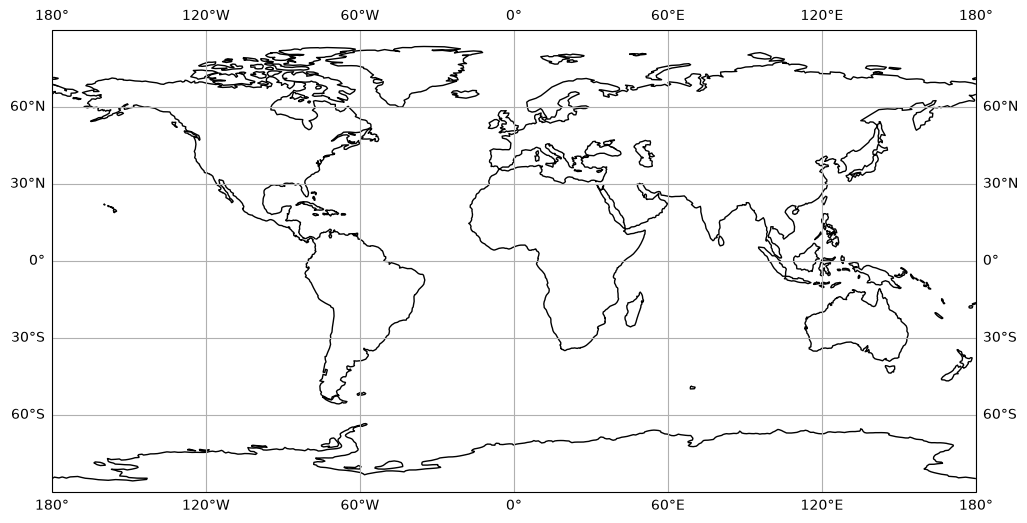

In [20]:
# Example: quick visualization of retrieved data
# (requires matplotlib, cartopy, and xarray)

def quick_plot(data, variable_name="Surface pressure", cmap="viridis"):
    """Quick plot of first time step of the first variable.

    Data is converted to xarray.  For HEALPix / unstructured grids the
    latitude/longitude coordinates are used with pcolormesh; for regular
    grids the standard xarray `.plot()` is used.
    """
    try:
        import cartopy.crs as ccrs
        import matplotlib.pyplot as plt
    except ImportError as e:
        print(f"⚠ matplotlib/cartopy not available: {e}")
        return

    try:
        ds = data.to_xarray()
    except Exception as e:
        print(f"⚠ Could not convert to xarray: {e}")
        return

    first_var = list(ds.data_vars)[0]
    da = ds[first_var]

    try:
        fig = plt.figure(figsize=(12, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.coastlines()
        ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

        if "time" in da.dims:
            da = da.isel(time=0)

        # ── Unstructured (HEALPix-style): render with scatter ──────
        if "latitude" in da.coords and "longitude" in da.coords:
            # Squeeze leftover dims so lat/lon & data are all 1-D
            da = da.squeeze()
            # Use marker size appropriate for standard (nside 128) vs high (nside 1024)
            npts = da.size
            s = 20 if npts < 200_000 else 0.5
            ax.scatter(
                da.coords["longitude"].values,
                da.coords["latitude"].values,
                c=da.values, s=s, cmap=cmap,
                transform=ccrs.PlateCarree(),
            )
        else:
            # Regular grid — use xarray's built-in plot
            da.plot(ax=ax, cmap=cmap, transform=ccrs.PlateCarree())

        ax.set_title(f"{variable_name} ({first_var})")
        plt.show()
    except Exception as e:
        print(f"⚠ Plot failed for {first_var}: {e}")

# Uncomment to plot if data was successfully retrieved:
if "icon_data" in dir():
    quick_plot(icon_data, "ICON Surface Pressure")


## 5. Low-Level Access with polytope-client

For advanced use cases, use the lower-level `polytope-client` directly.

In [10]:
# Using the low-level polytope-client (requires explicit credentials
# or ~/.polytopeapirc)

from polytope.api import Client

# ICON/IFS-FESOM → LUMI, IFS-NEMO → MN5
# client = Client(address=get_address('ICON'))

# Cancel any pending requests from previous sessions
# client.revoke("all")

# Download data
# files = client.retrieve(COLLECTION, request, output_path="./downloaded_data")
# print(f"Downloaded files: {files}")

print("Use the cell above with valid credentials to download via polytope-client.")
print("For most use cases, earthkit-data (sections above) is recommended.")

Use the cell above with valid credentials to download via polytope-client.
For most use cases, earthkit-data (sections above) is recommended.


## 6. Request Builder Helper

A flexible function to build request dictionaries for different scenarios.

In [ ]:
def build_request(
    model: str = "ICON",
    experiment: str = "hist",
    date: str = "20000615",
    time: str = "0000",
    param: str = "134",
    levtype: str = "sfc",
    realization: str = "1",
    **kwargs
) -> dict:
    """
    Build a Polytope request dictionary.
    
    Automatically sets the correct `activity` based on `experiment`:
      - 'hist' / 'cont'  → activity='baseline'
      - 'SSP3-7.0'       → activity='projections'
    
    Parameters
    ----------
    model : str
        Climate model: 'ICON', 'IFS-FESOM' (→ LUMI), 'IFS-NEMO' (→ MN5)
    experiment : str
        'cont' (control), 'hist' (historical), 'SSP3-7.0' (projections)
    date : str
        Date in YYYYMMDD format.
        'cont'/'hist' experiments typically use 1990–2014 dates,
        'SSP3-7.0' uses 2020–2050 dates.
    time : str
        Time in HHMM format, e.g. '0000' or '0000/0300/.../2100'
    param : str
        Parameter codes, e.g. '134' or '134/165/166'
    levtype : str
        'sfc' (surface), 'pl' (pressure levels), 'hl' (height levels)
    realization : str
        Ensemble realization number
    **kwargs
        Additional keys to add/override
    
    Returns
    -------
    dict
        Polytope request dictionary
    """
    # Map experiment to correct activity
    activity_map = {
        'hist': 'baseline',
        'cont': 'baseline',
        'SSP3-7.0': 'projections',
    }
    activity = activity_map.get(experiment, 'projections')
    
    request = {
        'activity': activity,
        'class': 'd1',
        'dataset': 'climate-dt',
        'date': date,
        'experiment': experiment,
        'expver': '0001',
        'generation': '2',
        'levtype': levtype,
        'model': model,
        'param': param,
        'realization': realization,
        'resolution': 'standard',
        'stream': 'clte',
        'time': time,
        'type': 'fc'
    }
    request.update(kwargs)
    return request


# Example: Build a request for surface data
example_request = build_request(
    model="IFS-FESOM",
    experiment="SSP3-7.0",
    date="20200615",
    time="0000/0600/1200/1800",
    param="134/165/166"
)

print("Example request for surface data:")
for key, value in example_request.items():
    print(f"  {key}: {value}")

## 7. Browsing Data Catalogue Programmatically

Use the Climate DT Explorer approach to discover available data.

In [9]:
# Explorer notebooks included locally in this directory:
# - browse_destine_data.ipynb  — Interactive browse & download
# - 03_lazy_browse_portfolio.ipynb  — Monthly catalogue (from polytope-examples)
#
# Additional notebooks:
# - 04_lazy_browse_portfolio_hourly.ipynb — Hourly catalogue
# - 05_variable_lookup.ipynb — Search for variables
#
# Repository: https://github.com/destination-earth-digital-twins/polytope-examples

print("Local explorer notebooks in get-data/:")
print("  browse_destine_data.ipynb         — Browse & download Climate DT data")
print("  03_lazy_browse_portfolio.ipynb    — Monthly catalogue")
print()
print("For interactive data exploration, see:")
print("https://github.com/destination-earth-digital-twins/polytope-examples/tree/main/climate-dt/explorer")


Local explorer notebooks in get-data/:
  browse_destine_data.ipynb         — Browse & download Climate DT data
  03_lazy_browse_portfolio.ipynb    — Monthly catalogue

For interactive data exploration, see:
https://github.com/destination-earth-digital-twins/polytope-examples/tree/main/climate-dt/explorer


## 8. Notes and Best Practices

- **Server addresses**: ICON and IFS-FESOM use the **LUMI** server (`polytope.lumi.apps.dte.destination-earth.eu`), IFS-NEMO uses the **MN5** server (`polytope.mn5.apps.dte.destination-earth.eu`).
- **Activity values**: Use `'baseline'` for hist/cont experiments and `'projections'` for SSP3-7.0.
- **Experiment names**: Use abbreviated forms: `'hist'` (historical), `'cont'` (control), `'SSP3-7.0'` (projections).
- **Date ranges**: Hist/cont experiments cover approx. 1990–2014. SSP3-7.0 projections start around 2015.
- **Streams**: The hourly `clte` stream contains instantaneous surface params (134 SP, 165 10U, 166 10V). Precipitation (228228) and temperature (167) are in the monthly `clmn` stream — use the `PolytopeZarrStore` approach from polytope-examples for monthly data.
- **Start small**: Test with a single time step and one parameter before requesting larger datasets.
- **Quota limits**: Max 2 concurrent downloads, 50 req/s. Be mindful of the server load.
- **Cache data**: Use `stream=False` to save retrieved data locally.
- **Authentication**: Keep `~/.polytopeapirc` valid. The token may expire.
- **For more info**: See `docs/polytope_usage.md` and `docs/data_catalogue.md`.